# PyGame visualization stack demo

This notebook demonstrates the repo's **visualization API** itself -- not a
full experiment run (see `basic_experiment.ipynb` for that end-to-end
walkthrough). The simulation's rendering stack lives entirely in
`basic/drawing/` and is PyGame-based, replacing an older Matplotlib renderer
(`basic/drawing/draw.py`, deleted; see git history) that this project no
longer uses:

| Module | What it does |
|---|---|
| `basic/drawing/pygame_draw.py` | `render_frame` / `save_frame_png` -- draws one frame of sim state into an offscreen `pygame.Surface`, no display needed. |
| `basic/drawing/video.py` | `write_video` / `FfmpegWriter` / `ffmpeg_exe` -- streams rendered frames straight into a piped `ffmpeg` process to produce an mp4. |
| `basic/drawing/live.py` | `LiveViewer` -- an interactive window (or, headless, an invisible "dummy"-driver surface) that drives itself from a caller's simulation loop, one tick at a time. |
| `experiments/live.py` | The CLI entry point wrapping `LiveViewer` for a real herding run. |

Three properties hold across the whole stack, and this notebook demonstrates
each one directly:

- **Display-free by design.** `pygame_draw.py` and `video.py` never call
  `pygame.init()` or any `pygame.display.*` function -- only an off-screen
  `pygame.Surface`. That is what makes every cell below runnable in this
  headless container with no X server or GPU.
- **No intermediate frames on disk.** `write_video` pipes each frame's raw
  RGBA bytes directly into `ffmpeg`'s stdin; nothing is ever written to disk
  per-frame, only the final encoded mp4.
- **Rendering never perturbs the simulation.** Every renderer is read-only on
  the sim's agent arrays and never draws from the shared RNG the simulation
  itself depends on for determinism -- proven bit-exactly in the last section
  below.

**Sections:**
1. Setup
2. A real frame (`save_frame_png`)
3. Mode overlays without re-importing (`render_frame`'s runtime `mode` arg)
4. mp4 export (`write_video`)
5. Live viewer (`experiments/live.py` / `LiveViewer`)
6. No-drift guarantee

In [1]:
import os

# Cap the numeric thread pools BEFORE numpy/numba/pygame first load them, and
# suppress pygame's stdout "Hello from the pygame community" banner -- both
# must be set before the relevant imports below run. This container shares a
# PID-budget cgroup with sibling sessions; an uncapped OpenBLAS spawns one
# thread per core, which can exhaust that budget for the ffmpeg encoder
# subprocesses this notebook spawns later (same pattern as
# basic_experiment.ipynb's setup cell).
for var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(var, "1")
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")

import random
import subprocess
import sys
from pathlib import Path
from timeit import default_timer as timer

import numba as nb
import numpy as np
import pygame
from IPython.display import Image, Video, display

# Resolve the repo root (the directory holding pyproject.toml) so paths work
# no matter whether Jupyter was launched from notebooks/ (the usual case) or
# the repo root itself. `import basic` already works when the kernel is the
# project venv (editable install); the sys.path insert covers any other
# kernel pointed at this notebook.
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    None,
)
assert REPO_ROOT is not None, "run this notebook from inside the repository"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Confirms the kernel is actually the project .venv (which has pygame,
# imageio-ffmpeg, and the editable `basic` install) -- a stray user-level
# "Python 3" kernelspec could otherwise shadow it silently.
print("kernel interpreter:", sys.executable)

from basic import MODE, TARGET, TARGET_SIZE, TARGET_X, TARGET_Y
from basic.drawing.pygame_draw import DEFAULT_CONFIG, render_frame, save_frame_png
from basic.drawing.video import ffmpeg_exe, write_video
from basic.herding.initiation import initiate, initiate_shepherds
from basic.herding.interaction import evolve

# The simulation's viewing/world window, computed exactly as
# experiments/test.py and experiments/live.py do: a fixed margin around the
# target circle.
BOUNDARY = (TARGET_X + TARGET_SIZE + 300, TARGET_Y + TARGET_SIZE + 300)

media_dir = REPO_ROOT / "notebooks" / "media"
media_dir.mkdir(parents=True, exist_ok=True)


# Design: numba's np.random state lives outside the interpreter's global RNG,
# so seeding must happen *inside* nopython-JIT'd code to reach the stream the
# jitted kernels actually draw from -- the same trick experiments/test.py's
# and experiments/live.py's `seed_run` use. Seeds BOTH the `random`-module
# and `np.random` streams: some kernels in basic/herding draw from one, some
# from the other, and both must be seeded identically for two runs with the
# same seed to be reproducible.
@nb.jit(nopython=True)
def seed_run(seed: int):
    """Seeds both RNG streams the simulation's jitted kernels can draw from."""
    random.seed(seed)
    np.random.seed(seed)


assert ffmpeg_exe() is not None, (
    "no ffmpeg on PATH, and imageio-ffmpeg is not installed"
)
print("ffmpeg executable:", ffmpeg_exe())
print("BOUNDARY:", BOUNDARY, "| TARGET:", TARGET, "| MODE (frozen at import):", MODE)

kernel interpreter: /workspace/Shepherding-Behavior/.venv/bin/python


ffmpeg executable: /workspace/Shepherding-Behavior/.venv/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2
BOUNDARY: (825, 825) | TARGET: (400, 400, 125) | MODE (frozen at import): 0


## A real frame

`save_frame_png` renders one real simulation snapshot to a PNG, entirely
offscreen. We run the same two-phase pipeline every experiment in this repo
uses:

1. **Flocking warm-up** -- 1000 shepherd-free ticks, so the sheep
   self-organize into a cohesive group before any shepherd shows up.
   *(The first `evolve()` call below JIT-compiles the whole force/update
   kernel chain -- roughly 20s of one-time cost. Every later `evolve()` call
   anywhere else in this notebook reuses that compiled function, so this is
   paid exactly once, here.)*
2. **Herding** -- 500 ticks with 2 real shepherds released.

Then `save_frame_png` writes the resulting state straight to
`notebooks/media/demo_frame.png`, with a HUD string overlaid.

initiating + JIT-compiling evolve() (~20s on this first call)...


warm-up done in 11.7s (1000 ticks)
wrote notebooks/media/demo_frame.png (25653 bytes)


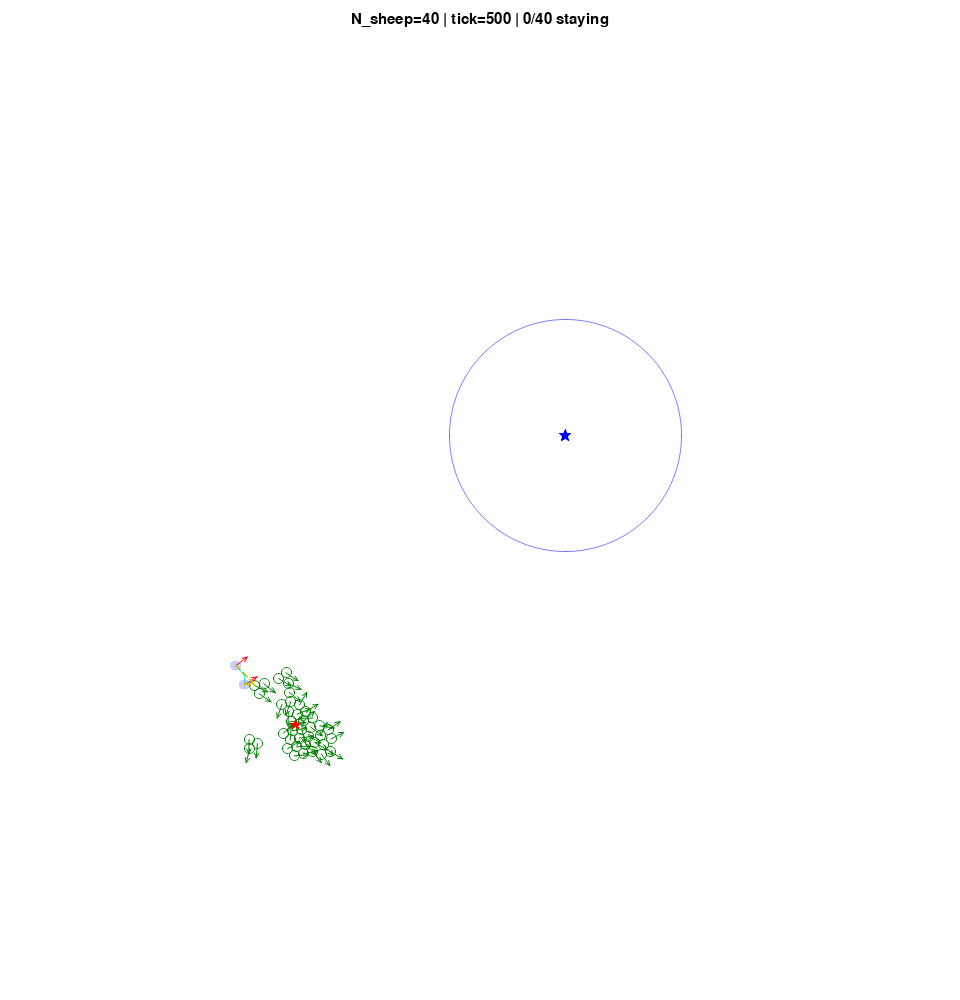

In [2]:
N_SHEEP = 40
N_SHEPHERD = 2
SPACE_X = SPACE_Y = 150
SEED = 0
FLOCK_TICKS = 1000  # shepherd-free self-organization warm-up
HERD_TICKS = 500  # herding ticks rendered in this section

L3 = np.sqrt(N_SHEEP / N_SHEPHERD) * 5  # shepherd-shepherd avoidance radius (as in test.py)

seed_run(SEED)
agents = initiate(N_SHEEP, N_SHEPHERD, SPACE_X, SPACE_Y, TARGET_SIZE)
shepherds = initiate_shepherds(0, N_SHEEP, L3)  # zero shepherds during warm-up

print("initiating + JIT-compiling evolve() (~20s on this first call)...")
t0 = timer()
for _ in range(FLOCK_TICKS):
    agents, shepherds, _ = evolve(agents, shepherds, *TARGET)
print(f"warm-up done in {timer() - t0:.1f}s ({FLOCK_TICKS} ticks)")

# Release the real shepherds and herd for HERD_TICKS.
shepherds = initiate_shepherds(N_SHEPHERD, N_SHEEP, L3)
for _ in range(HERD_TICKS):
    agents, shepherds, _ = evolve(agents, shepherds, *TARGET)

n_staying = int((agents[:, 21] == 1).sum())
hud = f"N_sheep={N_SHEEP} | tick={HERD_TICKS} | {n_staying}/{N_SHEEP} staying"
frame_path = media_dir / "demo_frame.png"
save_frame_png(str(frame_path), agents, shepherds, BOUNDARY, TARGET, MODE, hud=hud)
print(f"wrote {frame_path.relative_to(REPO_ROOT)} ({frame_path.stat().st_size} bytes)")
display(Image(filename=str(frame_path)))

## Mode overlays without re-importing

`basic.MODE` (the shepherd's flock-center strategy) is **frozen into the
numba-JIT'd kernels at import time** -- this whole notebook process only ever
runs `MODE = 0`, and switching strategies for real would mean editing
`basic/__init__.py` and restarting the kernel.

`render_frame`'s `mode` parameter is different: it is a **runtime** argument
that only controls which overlay gets *drawn*, independent of which strategy
actually *ran*. That means every overlay -- modes 2, 3, and 4 -- can be
demonstrated on a single hand-built synthetic `(swarm, shepherds)` pair, all
in this one process, just by calling `render_frame`/`save_frame_png` with a
different `mode` each time. No `evolve()` call, no kernel restart.

The synthetic swarm below (12 sheep, 2 shepherds) hand-populates exactly the
columns each overlay reads:

- **col 22** (hull rank): 8 sheep placed on a circle, ranked `1..8` in CCW
  angular order -- **mode 2** connects them with a dashed hull outline and
  marks the hull center with a black star.
- **col 23** (visibility bitmask) + the moving-sheep convex hull: **mode 3**
  draws each shepherd's magenta visibility rays to the sheep it can see, plus
  a magenta center-of-mass star per shepherd.
- **col 24** (subflock id): the 8 ring sheep are subflock 1, the remaining 4
  are subflock 2 -- **mode 4** draws one hull per subflock, in addition to
  the same visibility rays as mode 3.
- **`fence=(0.0, 1.0)`**: independent of `swarm`/`shepherds` entirely -- a
  1-radian gate arc drawn around the target circle.

In [3]:
def make_overlay_state():
    """
    Builds a small, hand-placed synthetic (swarm, shepherds) pair that
    exercises the mode-2/3/4 overlay columns all at once, so the SAME array
    can be re-rendered with a different `mode` argument below -- the point
    being that `basic.MODE` is frozen into the numba kernels at import time,
    but `render_frame`'s `mode` argument is not. Nothing here calls
    `evolve()`; every column is set by hand.

    Returns
    -------
    swarm : numpy.ndarray, shape (12, 25)
        8 sheep on a ring (subflock 1, hull-ranked 1..8 CCW) + 4 sheep in an
        off-center inner cluster (subflock 2, not hull members).
    shepherds : numpy.ndarray, shape (2, 22)
        Shepherd 0 (drive mode) sees the ring; shepherd 1 (collect mode)
        sees the inner cluster.
    """
    ring_center = np.array([150.0, 600.0])
    ring_radius = 120.0
    # Design: offset from ring_center (not centered on it) so the inner
    # cluster's own visibility-center star doesn't land on top of the ring's
    # -- the two mode-3/4 overlay stars stay visually distinguishable.
    inner_center = ring_center + np.array([-40.0, -40.0])

    swarm = np.zeros((12, 25))
    swarm[:, 7] = 5.0  # body radius (world units); render_frame only reads row 0

    # --- Outer ring: 8 sheep evenly spaced on a circle. These form the
    # convex hull for modes 2/3 and subflock 1 for mode 4. Hull rank (col 22)
    # is assigned in the SAME order the angles increase (CCW) -- an
    # arbitrary rank assignment would make mode 2's dashed polygon zig-zag
    # across the circle instead of tracing its outline.
    ring_angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
    ring_xy = ring_center + ring_radius * np.stack(
        [np.cos(ring_angles), np.sin(ring_angles)], axis=1
    )
    swarm[0:8, 0:2] = ring_xy
    swarm[0:8, 2] = ring_angles  # heading points outward, for a readable arrow
    swarm[0:8, 22] = np.arange(1, 9)  # hull rank 1..8, CCW
    swarm[0:8, 24] = 1  # subflock 1

    # --- Inner cluster: 4 sheep, asymmetric scatter around inner_center.
    # Must stay strictly inside the ring (so they are NOT hull members) and
    # must not be collinear -- scipy's ConvexHull (used by modes 3/4) raises
    # QhullError on a degenerate point set, which a symmetric or evenly
    # spaced layout risks.
    inner_offsets = np.array(
        [[15.0, 10.0], [-10.0, 18.0], [-18.0, -8.0], [8.0, -20.0]]
    )
    swarm[8:12, 0:2] = inner_center + inner_offsets
    swarm[8:12, 24] = 2  # subflock 2
    # col 22 (hull rank) stays 0 for the inner sheep: not on the outer hull.

    # --- Visibility bitmasks (col 23): shepherd 0 sees the 8 ring sheep,
    # shepherd 1 sees the 4 inner sheep. Bit i corresponds to shepherd i,
    # smuggled into a float64 lane exactly as basic.herding.interaction
    # writes it (see pygame_draw's module docstring, "Data contract").
    bit0 = np.array([0b01], dtype=np.uint64).view(np.float64)[0]
    bit1 = np.array([0b10], dtype=np.uint64).view(np.float64)[0]
    swarm[0:8, 23] = bit0
    swarm[8:12, 23] = bit1

    # --- Shepherds: both placed OUTSIDE the ring (radius 120), on opposite
    # sides, so their visibility-ray fans (mode 3/4) don't overlap visually.
    shepherds = np.zeros((2, 22))
    shepherd0_xy = ring_center + np.array([0.0, 170.0])
    shepherd1_xy = ring_center + np.array([-150.0, -110.0])
    shepherds[0, 0:2] = shepherd0_xy
    shepherds[1, 0:2] = shepherd1_xy
    # Headings point from each shepherd toward what it's tracking, purely
    # for a readable picture -- render_frame doesn't care what a heading
    # "means", it just draws the arrow.
    shepherds[0, 2] = np.arctan2(
        ring_center[1] - shepherd0_xy[1], ring_center[0] - shepherd0_xy[0]
    )
    shepherds[1, 2] = np.arctan2(
        inner_center[1] - shepherd1_xy[1], inner_center[0] - shepherd1_xy[0]
    )
    shepherds[0, 13] = 1  # drive mode (rendered red)
    shepherds[1, 13] = 0  # collect mode (rendered blue, + a yellow tether)
    shepherds[0, 14:16] = ring_center  # shepherd 0's drive point: flock center
    collect_target = 8  # index of the inner sheep shepherd 1 is "collecting"
    shepherds[1, 14:16] = swarm[collect_target, 0:2]
    shepherds[1, 16] = collect_target

    return swarm, shepherds


syn_swarm, syn_shepherds = make_overlay_state()
print(f"synthetic swarm: {syn_swarm.shape[0]} sheep, {syn_shepherds.shape[0]} shepherds")

synthetic swarm: 12 sheep, 2 shepherds


Mode 2 -- convex hull via col 22 hull rank (dashed green) + hull-center star (black)


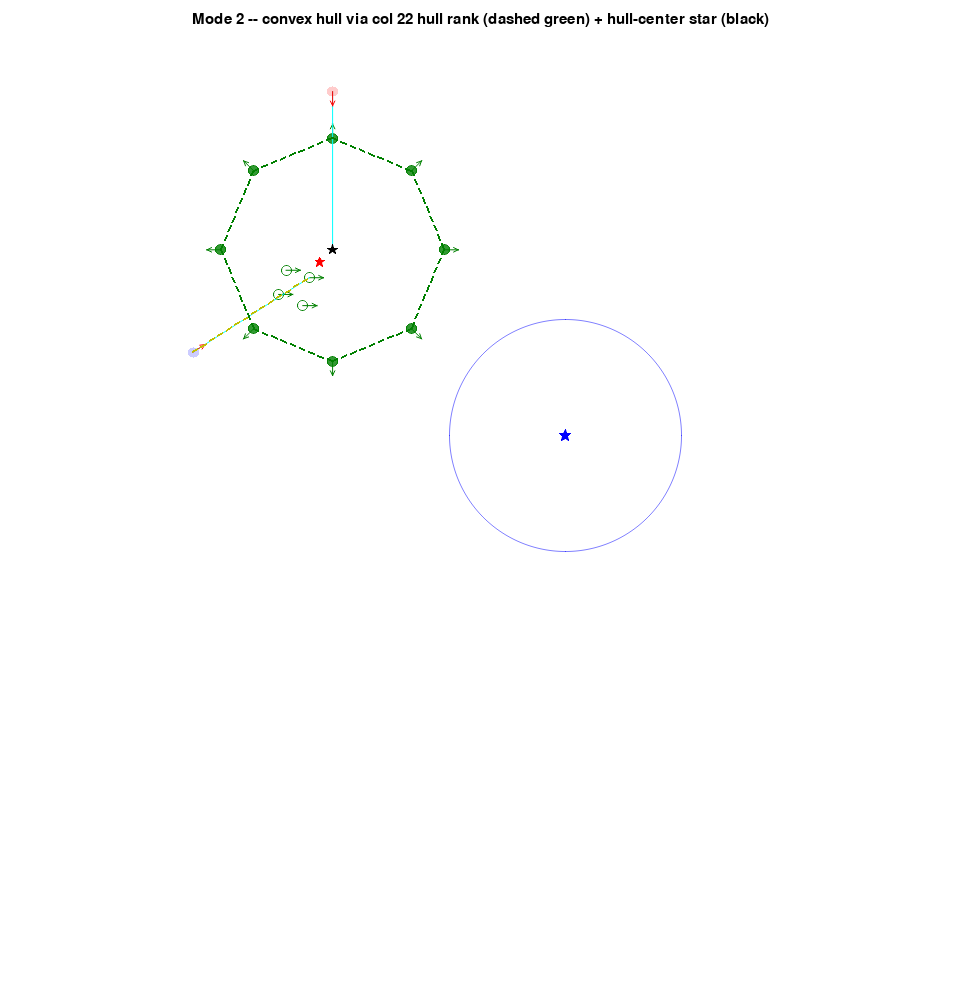

Mode 3 -- moving-sheep hull + per-shepherd visibility rays/stars (magenta, from col 23)


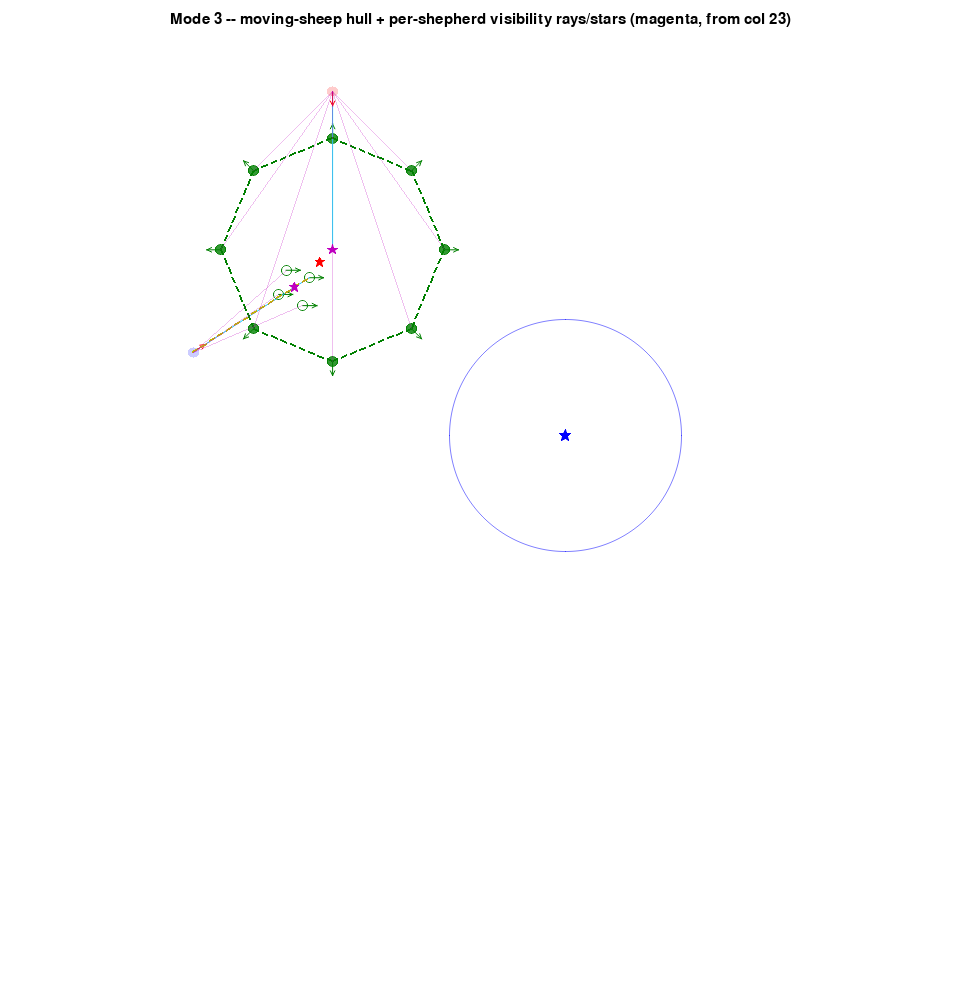

Mode 4 -- one hull per subflock (col 24) + visibility rays


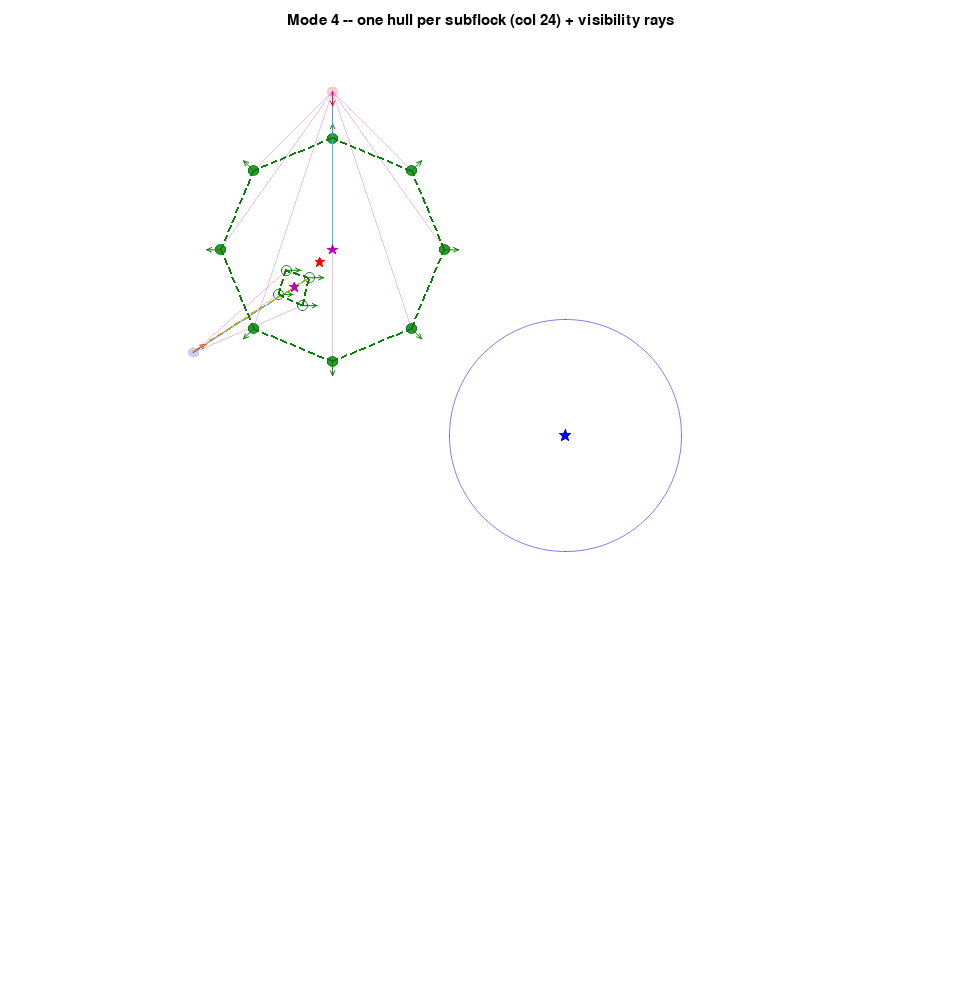

Mode 0, fence=(0.0, 1.0) -- a 1-radian gate arc (red) around the target


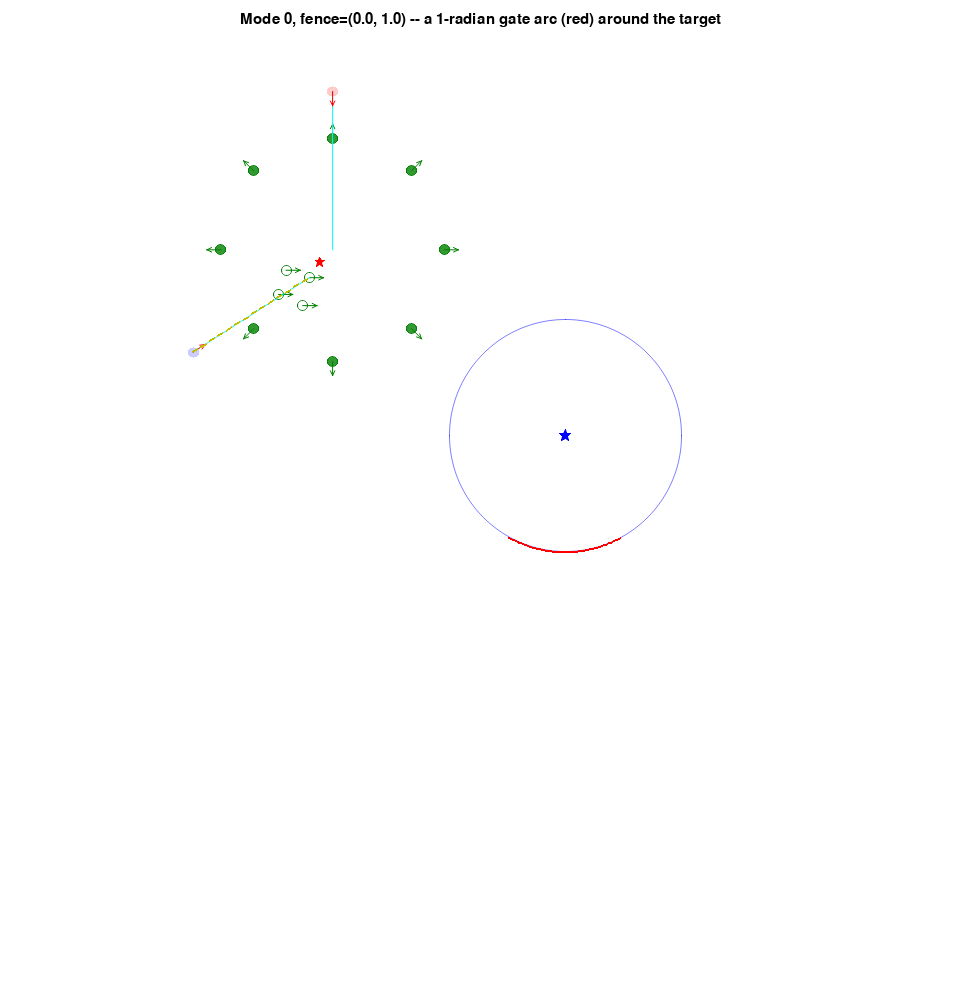

In [4]:
# Same synthetic (syn_swarm, syn_shepherds) pair, rendered 4 times with a
# different runtime `mode` (and, for the last one, a `fence`) each time --
# demonstrating that the overlay is chosen at render time, not at import
# time. All four PNGs go to notebooks/media/ alongside demo_frame.png.
overlay_renders = [
    ("demo_mode2.png", 2, None,
     "Mode 2 -- convex hull via col 22 hull rank (dashed green) "
     "+ hull-center star (black)"),
    ("demo_mode3.png", 3, None,
     "Mode 3 -- moving-sheep hull + per-shepherd visibility rays/stars "
     "(magenta, from col 23)"),
    ("demo_mode4.png", 4, None,
     "Mode 4 -- one hull per subflock (col 24) + visibility rays"),
    ("demo_fence.png", 0, (0.0, 1.0),
     "Mode 0, fence=(0.0, 1.0) -- a 1-radian gate arc (red) around the target"),
]

for filename, mode, fence, caption in overlay_renders:
    path = media_dir / filename
    save_frame_png(
        str(path), syn_swarm, syn_shepherds, BOUNDARY, TARGET, mode,
        hud=caption, fence=fence,
    )
    print(caption)
    display(Image(filename=str(path)))

## mp4 export

`write_video` re-renders a sequence of recorded frames into a single reused,
offscreen `pygame.Surface` and streams each one's raw RGBA bytes straight
into a piped `ffmpeg` process -- no intermediate PNGs or other per-frame
files ever touch disk.

We continue the **real** run from the "A real frame" section above (it's
already mid-herding) for `ADDITIONAL_TICKS` more ticks, snapshotting the
full `(agents, shepherds)` state into `(N, F, frames)` cubes every
`RECORD_INTERVAL` ticks (plus the true final tick, whether that's a success
or a timeout), then hand the cubes to `write_video`.

In [5]:
RECORD_INTERVAL = 50
ADDITIONAL_TICKS = 4000

n_slots = ADDITIONAL_TICKS // RECORD_INTERVAL + 2
data_agents = np.zeros((agents.shape[0], agents.shape[1], n_slots))
data_shepherds = np.zeros((shepherds.shape[0], shepherds.shape[1], n_slots))
frame_ticks = np.zeros(n_slots, dtype=int)
frame = 0
tick_offset = HERD_TICKS  # herding ticks already elapsed (the previous section)

start = timer()
done = False
i = 0
for i in range(ADDITIONAL_TICKS):
    agents, shepherds, _ = evolve(agents, shepherds, *TARGET)
    tick = tick_offset + i
    done = bool(np.all(agents[:, 21] == 1))
    # Record every RECORD_INTERVAL-th tick, plus unconditionally the true
    # final tick (a success or the last tick of the budget) -- mirrors
    # experiments/test.py's / basic_experiment.ipynb's recording convention,
    # so the video always ends on the actual final state rather than
    # potentially stopping up to RECORD_INTERVAL - 1 ticks early.
    if i % RECORD_INTERVAL == 0 or done or i == ADDITIONAL_TICKS - 1:
        data_agents[:, :, frame] = agents
        data_shepherds[:, :, frame] = shepherds
        frame_ticks[frame] = tick
        frame += 1
    if done:
        break
elapsed = timer() - start
print(
    f"{'SUCCESS' if done else 'still herding'} after {i + 1} more ticks "
    f"({frame} frames recorded, {elapsed:.1f}s)"
)

video_path = media_dir / "demo_run.mp4"
write_video(
    (frame_ticks[:frame], L3, MODE),
    (data_agents[:, :, :frame], data_shepherds[:, :, :frame]),
    BOUNDARY,
    TARGET,
    str(video_path),
)

# FfmpegWriter deletes its stderr .log file on a successful encode (see
# basic/drawing/video.py) -- its continued presence would mean the encode
# actually failed silently from this cell's point of view.
log_path = video_path.with_suffix(video_path.suffix + ".log")
assert video_path.exists() and video_path.stat().st_size > 0, "demo_run.mp4 missing or empty"
assert not log_path.exists(), "ffmpeg .log left behind -- indicates the encode did not exit cleanly"
print(f"wrote {video_path.relative_to(REPO_ROOT)} ({video_path.stat().st_size / 1024:.0f} KB)")

still herding after 4000 more ticks (81 frames recorded, 0.1s)


wrote notebooks/media/demo_run.mp4 (171 KB)


In [6]:
# embed=True base64-inlines the mp4 into the saved .ipynb, so it plays on its
# own (e.g. on GitHub/nbviewer) without notebooks/media/ (gitignored) sitting
# next to it.
Video(str(video_path), embed=True, width=640, html_attributes="controls loop")

## Live viewer

`experiments/live.py` runs the identical initiate -> flock -> herd pipeline
as everything above, but drives a `basic.drawing.live.LiveViewer` instead of
saving PNGs or an mp4: on a machine with a real display it opens an
interactive PyGame window, updated live as the simulation runs.

**Keys** (while a window is open): `space` pause/resume, `right`/`.`
single-step while paused, `+`/`=` halve the render cadence (draw more often),
`-` double it (draw less often), `s` screenshot the current frame, `esc`/`q`
quit.

Two flags matter for this container:
- `--headless-ok` permits running with no display at all, by rendering into
  an invisible SDL "dummy" surface instead of raising.
- `--record PATH` tees every drawn frame into an mp4 via the same
  `FfmpegWriter` `write_video` uses above -- this works identically whether
  or not there's a real window to also show it in.

Since this is a *script*, not an importable function, we demonstrate it
exactly as a user would from a terminal: as a subprocess. It pays its own
~20s JIT-compile cost (a fresh process has no compiled `evolve()` to reuse).

In [7]:
live_mp4 = media_dir / "demo_live.mp4"
live_cmd = [
    sys.executable, str(REPO_ROOT / "experiments" / "live.py"),
    "--sheep", "20",
    "--shepherds", "2",
    "--flock-ticks", "200",
    "--max-iterations", "1500",
    "--render-every", "100",
    "--headless-ok",
    "--record", str(live_mp4),
    "--out", str(media_dir),
]
# SDL_VIDEODRIVER=dummy is what LiveViewer treats as explicit consent to
# invisible rendering (see live.py's __init__ docstring/Notes). Merge into
# (never replace) the parent environment -- a bare {"SDL_VIDEODRIVER":
# "dummy"} dict would strip PATH (breaking the subprocess's own ffmpeg
# lookup) and this cell's thread-cap env vars.
live_env = {**os.environ, "SDL_VIDEODRIVER": "dummy"}

print("running experiments/live.py as a subprocess (pays its own ~20s JIT)...")
t0 = timer()
result = subprocess.run(
    live_cmd, env=live_env, capture_output=True, text=True, timeout=300,
)
print(f"finished in {timer() - t0:.1f}s, exit code {result.returncode}")
print("--- stdout tail ---")
print("\n".join(result.stdout.strip().splitlines()[-15:]))

# Exit codes (see experiments/live.py's module docstring): 0 = herding
# succeeded (or the run quit cleanly); 2 = the tick budget ran out without
# success, but a final frame was still rendered/recorded -- both are a clean
# demo run here. Anything else means the subprocess crashed.
if result.returncode not in (0, 2):
    print("--- stderr ---")
    print(result.stderr[-4000:])
assert result.returncode in (0, 2), f"experiments/live.py crashed (exit {result.returncode})"
assert live_mp4.exists() and live_mp4.stat().st_size > 0, "demo_live.mp4 missing or empty"
print(f"wrote {live_mp4.relative_to(REPO_ROOT)} ({live_mp4.stat().st_size / 1024:.0f} KB)")

running experiments/live.py as a subprocess (pays its own ~20s JIT)...


finished in 16.0s, exit code 2
--- stdout tail ---
MODE=0 MORPHOLOGY=False | 20 sheep, 2 shepherds, seed 0
initiating + JIT-compiling evolve (~20s on first call)...
first evolve call took 14.4s
herding phase starting -- keys: space=pause, right/.=step, +/-=render-every, s=screenshot, esc/q=quit
TIMEOUT: final_tick=1500 (6234 ticks/s)
wrote notebooks/media/demo_live.mp4 (32 KB)


In [8]:
Video(str(live_mp4), embed=True, width=640, html_attributes="controls loop")

## No-drift guarantee

The simulation is deterministic but chaotic: every tick draws exactly
`1 + N_shepherd` values from one shared global RNG stream (numpy's, seeded
inside JIT'd code -- see `seed_run` above), and even a single ULP of
floating-point difference can eventually flip a discrete threshold (a sheep's
staying flag, a shepherd's collect/drive switch, ...) into a different
trajectory. That makes rendering uniquely dangerous to get wrong: if any
renderer secretly drew from that same RNG stream (or mutated the agent
arrays it was handed), attaching a live viewer or recorder to a run would
silently desync it from an otherwise-identical run that wasn't being
watched.

Every renderer in this stack is documented as read-only on `swarm`/
`shepherds` and never calls `random`/`np.random` (see `pygame_draw.py`'s
module docstring). We check that claim directly: run two fresh,
identically-seeded flocks, one plain and one rendered into an offscreen
`Surface` on *every single tick*, and byte-compare their final states.

In [9]:
def run_plain(seed, n_sheep, n_shepherd, ticks):
    """Runs `ticks` herding steps from a fresh seed; no rendering at all.

    This is the baseline the rendered run below is compared against.

    Parameters
    ----------
    seed : int
        RNG seed, applied via `seed_run` before anything else.
    n_sheep, n_shepherd : int
        Flock/shepherd counts forwarded to `initiate`/`initiate_shepherds`.
    ticks : int
        Number of `evolve()` calls to run.

    Returns
    -------
    agents : numpy.ndarray, shape (n_sheep, 25)
    shepherds : numpy.ndarray, shape (n_shepherd, 22)
        Final state after `ticks` herding steps.
    """
    seed_run(seed)
    l3_small = np.sqrt(n_sheep / n_shepherd) * 5
    a = initiate(n_sheep, n_shepherd, SPACE_X, SPACE_Y, TARGET_SIZE)
    s = initiate_shepherds(n_shepherd, n_sheep, l3_small)
    for _ in range(ticks):
        a, s, _ = evolve(a, s, *TARGET)
    return a, s


def run_rendered(seed, n_sheep, n_shepherd, ticks):
    """Identical to `run_plain`, except every tick is also rendered.

    Renders into a single reused offscreen `pygame.Surface` via
    `render_frame` -- the same call `write_video` makes per frame, just at
    every tick instead of every `DRAW_INTERVAL`-th one. If `render_frame`'s
    read-only/RNG-free contract holds, this run's final state must be
    byte-identical to `run_plain`'s, since both consume the identical RNG
    stream from the identical seed.

    Parameters
    ----------
    seed, n_sheep, n_shepherd, ticks
        Same as `run_plain`.

    Returns
    -------
    agents : numpy.ndarray, shape (n_sheep, 25)
    shepherds : numpy.ndarray, shape (n_shepherd, 22)
        Final state after `ticks` herding steps, with every tick also
        rendered.
    """
    seed_run(seed)
    l3_small = np.sqrt(n_sheep / n_shepherd) * 5
    a = initiate(n_sheep, n_shepherd, SPACE_X, SPACE_Y, TARGET_SIZE)
    s = initiate_shepherds(n_shepherd, n_sheep, l3_small)
    surface = pygame.Surface(DEFAULT_CONFIG.window_size)
    for _ in range(ticks):
        a, s, _ = evolve(a, s, *TARGET)
        render_frame(surface, a, s, BOUNDARY, TARGET, MODE)
    return a, s


DRIFT_SEED = 12345
DRIFT_N_SHEEP = 15  # small, purely for wall-clock speed -- unrelated to the claim being tested
DRIFT_N_SHEPHERD = 2
DRIFT_TICKS = 500

agents_plain, shepherds_plain = run_plain(
    DRIFT_SEED, DRIFT_N_SHEEP, DRIFT_N_SHEPHERD, DRIFT_TICKS
)
agents_rendered, shepherds_rendered = run_rendered(
    DRIFT_SEED, DRIFT_N_SHEEP, DRIFT_N_SHEPHERD, DRIFT_TICKS
)

# Compared as raw bytes (.view("uint8")), not np.allclose: the claim is BIT-
# exact identity, not numerical closeness -- any drift at all, even one ULP,
# would mean render_frame perturbed the RNG stream or the arrays themselves.
agents_identical = np.array_equal(
    agents_plain.view("uint8"), agents_rendered.view("uint8")
)
shepherds_identical = np.array_equal(
    shepherds_plain.view("uint8"), shepherds_rendered.view("uint8")
)
print(f"agents identical:    {agents_identical}")
print(f"shepherds identical: {shepherds_identical}")
assert agents_identical and shepherds_identical, (
    "rendering perturbed the simulation -- no-drift guarantee violated"
)
print("no-drift guarantee holds: rendering every tick changed nothing.")

agents identical:    True
shepherds identical: True
no-drift guarantee holds: rendering every tick changed nothing.


## Where to go next

- **Live viewer, interactively:** the README's
  [*Live viewer*](../README.md#live-viewer) section covers running
  `experiments/live.py` yourself on a machine with a real display, plus the
  full CLI flag list.
- **The full experiment walkthrough:** `basic_experiment.ipynb`, in this same
  directory, runs one repetition of the end-to-end point-to-point herding
  experiment (`experiments/test.py`'s single-rep equivalent) from a fresh
  flock all the way to a played-back video -- this notebook, by contrast,
  exists purely to demonstrate the visualization API surface itself.